In [56]:
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from sklearn.model_selection import train_test_split
from sksurv.ensemble import RandomSurvivalForest
from sksurv.linear_model import CoxPHSurvivalAnalysis
from sksurv.metrics import concordance_index_censored , concordance_index_ipcw
from sklearn.impute import SimpleImputer
from sksurv.util import Surv

In [57]:
df = pd.read_csv(".\X_train\clinical_train.csv")
gene_df = pd.read_csv('.\X_train\molecular_train.csv')
target_df = pd.read_csv('target_train.csv')

In [58]:
def isNormal(karotype):
    reg = r'^(46,x[xy]\[\d{1,2}\]|46,x[xy])$'
    match = re.match(reg,karotype)
    if match:
        return True
    else:
        return False

def extractNormalCells(karotype):
    reg = r'^46,x[xy]\[(\d{1,2})\]$'
    m1 = re.match(r'^46,x[xy]$',karotype)
    if m1:
        return 20
    match = re.match(reg,karotype)
    if match:
        return int(match.group(1))
    else:
        return 0

def extractAbnormalCells(karotype):
    reg = r'\[(\d{1,2})\]$'
    m1 = re.search(r'complex',karotype)
    if m1:
        return 20
    match = re.search(reg,karotype)
    if not isNormal(karotype):
        if match:
            return int(match.group(1))
        else:
            return 0

def extractAbnormalityTypes(karotype,abnormality):
    c = karotype.count(abnormality)
    return c

def countMonosomy(karotype):
    reg = r'-\d{1,2}'
    match = re.findall(reg,karotype)
    return len(match)

def addColumns(row):
    abnormal = 0
    normal = 0
    deletions = 0
    additions = 0
    inversions = 0
    translocations = 0
    monosomy = 0
    isComplex = 0
    karotype = row['CYTOGENETICS']
    if not isinstance(karotype,str):
        row['ABNORMAL_CELL_COUNT'] = None
        row['NORMAL_CELL_COUNT'] = None
        row['IS_COMPLEX'] = isComplex
        row['DELETIONS'] = None
        row['ADDITIONS'] = None
        row['INVERSIONS'] = None
        row['TRANSLOCATIONS'] = None 
        row['MONOSOMY'] = None
        return row
        
    if karotype == 'complex':
        isComplex = 1

    karotypes = karotype.split('/')
    for k in karotypes:
        if isNormal(k):
            normal += extractNormalCells(k)
        else:
            abnormal += extractAbnormalCells(k)
            deletions += extractAbnormalityTypes(k,'del')
            additions += extractAbnormalityTypes(k,'add')
            inversions += extractAbnormalityTypes(k,'inv')
            translocations += extractAbnormalityTypes(k,'t')
            monosomy += countMonosomy(k)
    
    row['ABNORMAL_CELL_COUNT'] = abnormal
    row['NORMAL_CELL_COUNT'] = normal
    row['IS_COMPLEX'] = isComplex
    row['DELETIONS'] = deletions
    row['ADDITIONS'] = additions
    row['INVERSIONS'] = inversions
    row['TRANSLOCATIONS'] = translocations 
    row['MONOSOMY'] = monosomy
    return row
        
#t = extractNormalCells('46,xy')
#print(t)


In [59]:
df = df.apply(addColumns,axis=1)

In [60]:
gene_df.head()

,ID,CHR,START,END,REF,ALT,GENE,PROTEIN_CHANGE,EFFECT,VAF,DEPTH
0,P100000,11,119149248.0,119149248.0,G,A,CBL,p.C419Y,non_synonymous_codon,0.0830,1308.0
1,P100000,5,131822301.0,131822301.0,G,T,IRF1,p.Y164*,stop_gained,0.0220,532.0
2,P100000,3,77694060.0,77694060.0,G,C,ROBO2,p.?,splice_site_variant,0.4100,876.0
3,P100000,4,106164917.0,106164917.0,G,T,TET2,p.R1262L,non_synonymous_codon,0.4300,826.0
4,P100000,2,25468147.0,25468163.0,ACGAAGAGGGGGTGTTC,A,DNMT3A,p.E505fs*141,frameshift_variant,0.0898,942.0


In [61]:
len(gene_df['EFFECT'].unique())

16

276.22120448819925


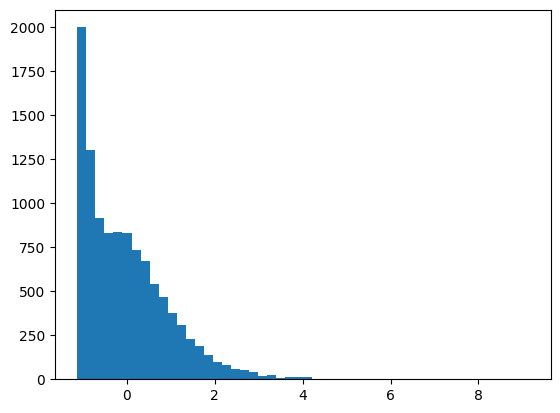

In [62]:
import matplotlib.pyplot as plt
import math

s = []
for idx,row in gene_df.iterrows():
    a = row['VAF']*row['DEPTH']
    if not math.isnan(a):
        s.append(a)

mean = np.mean(s)
dev = np.std(s)
print(dev)
z = [(x-mean)/dev for x in s]
l = [math.log(d) for d in gene_df['DEPTH']]
plt.hist(z,bins=50)
plt.show()

In [63]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="median")

columns = ['BM_BLAST', 'WBC','HB', 'PLT','ANC','MONOCYTES','ABNORMAL_CELL_COUNT','NORMAL_CELL_COUNT','DELETIONS','ADDITIONS','INVERSIONS','TRANSLOCATIONS','MONOSOMY']
df[columns] = imputer.fit_transform(df[columns])
df['PERCENT_ABNORMAL'] = df['ABNORMAL_CELL_COUNT']/(df['ABNORMAL_CELL_COUNT']+df['NORMAL_CELL_COUNT'])
df['PERCENT_ABNORMAL'] = df['PERCENT_ABNORMAL'].fillna(0)

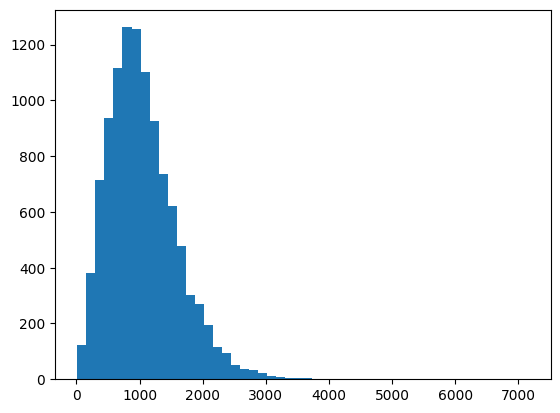

1051.2295536456888
975.0


In [64]:
temp = df.merge(gene_df,how='left',on=['ID'])
temp['VAF'] = temp['VAF'].fillna(0)
temp[temp['VAF'].isna()].shape

plt.hist(temp[temp['DEPTH'].notna()]['DEPTH'],bins=50)
plt.show()
print(np.mean(temp[temp['DEPTH'].notna()]['DEPTH']))
print(np.median(temp[temp['DEPTH'].notna()]['DEPTH']))

In [65]:
def createVAFVector(df):
    temp = df.merge(gene_df,how='left',on=['ID'])
    temp['VAF'] = temp['VAF'].fillna(0)
    temp['DEPTH'] = temp['DEPTH'].fillna(975) #median value of depth
    temp['VALUE'] = temp['VAF']*temp['DEPTH']
    wide = temp.pivot_table(index="ID",
                          columns="",
                          values="VALUE",
                          fill_value=0)
    wide = wide.reindex(df['ID'], fill_value=0)
    wide =wide.reset_index()
    wide_cols = wide.columns.tolist()
    if 'ID' in wide_cols:
        wide_cols.remove('ID')
    wide['VAF_VECTOR'] = wide[wide_cols].values.tolist()
    final = df.merge(wide[['ID','VAF_VECTOR']],how='inner',on=['ID'])
    return final

In [66]:
df = createVAFVector(df)

In [67]:
'''
Method to create a one hot encoded vector for encoding categorical variables
currentCol = categorical column to be one hot encoded and vectorised
newName - new name of the column created that stores the one hot encoded vector of categorical variables
'''

def createVector(df,currentCol,newName):
    temp = df.merge(gene_df,how='left',on=['ID'])
    temp = temp[['ID',currentCol]]
    wide = pd.crosstab(temp['ID'],temp[currentCol])
    wide = (wide>0).astype(int)
    wide = wide.reindex(df['ID'],fill_value=0)
    wide = wide.reset_index()
    wide_cols = wide.columns.tolist()
    if 'ID' in wide_cols:
        wide_cols.remove('ID')
    wide[newName] = wide[wide_cols].values.tolist()
    final = df.merge(wide[['ID',newName]],how='inner',on = ['ID'])
    return final



In [68]:
df = createVector(df,'EFFECT','EFFECT_VECTOR')
df = createVector(df,'GENE','GENE_VECTOR')
df = createVector(df,'CHR','CHR_VECTOR')

#df = df.merge(gene_df[['ID','EFFECT_VECTOR','GENE_VECTOR','CHR_VECTOR']], how = 'inner',on=['ID'])

In [69]:
df.columns.tolist()

['ID',
 'CENTER',
 'BM_BLAST',
 'WBC',
 'ANC',
 'MONOCYTES',
 'HB',
 'PLT',
 'CYTOGENETICS',
 'ABNORMAL_CELL_COUNT',
 'NORMAL_CELL_COUNT',
 'IS_COMPLEX',
 'DELETIONS',
 'ADDITIONS',
 'INVERSIONS',
 'TRANSLOCATIONS',
 'MONOSOMY',
 'PERCENT_ABNORMAL',
 'VAF_VECTOR',
 'EFFECT_VECTOR',
 'GENE_VECTOR',
 'CHR_VECTOR']

In [70]:
target = ['OS_YEARS', 'OS_STATUS']

target_df.dropna(subset=['OS_YEARS', 'OS_STATUS'], inplace=True)

# Check the data types to ensure 'OS_STATUS' is boolean and 'OS_YEARS' is numeric
print(target_df[['OS_STATUS', 'OS_YEARS']].dtypes)

# Contarget_dfvert 'OS_YEARS' to numeric if it isn’t already
target_df['OS_YEARS'] = pd.to_numeric(target_df['OS_YEARS'], errors='coerce')

# Ensure 'OS_STATUS' is boolean
target_df['OS_STATUS'] = target_df['OS_STATUS'].astype(bool)


# Create the survival data format
X = df[df['ID'].isin(target_df['ID'])]
y = Surv.from_dataframe('OS_STATUS', 'OS_YEARS', target_df)

OS_STATUS    float64
OS_YEARS     float64
dtype: object


In [71]:
print(X.shape)
print(len(y))

(3173, 22)
3173


In [72]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [73]:
def createReferenceVector(df,columnName):
    veclength = len(df[columnName].iloc[0])
    ref = np.array([0]*veclength)
    temp = df.merge(target_df,how='left',on=['ID'])
    dead = temp[temp['OS_STATUS'] == 1]
    c = 0
    for effect in dead[columnName]:
        ref += np.array(effect)
        c+=1

    ref = ref/c
    return ref

def cosine_sim(effect,reference):
    effect_arr = np.array(effect)
    s = np.dot(effect_arr,reference)
    mag1 = np.linalg.norm(effect_arr)
    mag2 = np.linalg.norm(reference)
    if mag1*mag2 == 0:
        return 0.0
    norm = s/(mag1*mag2)
    return norm



In [74]:
effect_ref_vector = createReferenceVector(X_train,'EFFECT_VECTOR')
gene_ref_vector = createReferenceVector(X_train,'GENE_VECTOR')
chromosome_ref_vector = createReferenceVector(X_train,'CHR_VECTOR')

In [75]:
X_train['EFFECT_DISTANCE'] = X_train['EFFECT_VECTOR'].apply(lambda v: cosine_sim(v,effect_ref_vector))
X_train['GENE_DISTANCE'] = X_train['GENE_VECTOR'].apply(lambda v: cosine_sim(v,gene_ref_vector))
X_train['CHR_DISTANCE'] = X_train['CHR_VECTOR'].apply(lambda v: cosine_sim(v,chromosome_ref_vector))
X_train['VAF_DISTANCE'] = X_train['VAF_VECTOR'].apply(lambda v: cosine_sim(v,effect_ref_vector))

In [76]:
#features = ["BM_BLAST","WBC","HB","PLT","PERCENT_ABNORMAL",'DELETIONS','INVERSIONS','MONOSOMY','IS_COMPLEX',"EFFECT_DISTANCE"] #0.69 on train

features = ["BM_BLAST","WBC","HB","PLT","PERCENT_ABNORMAL",'DELETIONS','INVERSIONS','MONOSOMY','IS_COMPLEX',
            "EFFECT_DISTANCE","GENE_DISTANCE","CHR_DISTANCE","VAF_DISTANCE"]

X_train = X_train[features]


In [77]:
X_train.head()

,BM_BLAST,WBC,HB,PLT,PERCENT_ABNORMAL,DELETIONS,INVERSIONS,MONOSOMY,IS_COMPLEX,EFFECT_DISTANCE,GENE_DISTANCE,CHR_DISTANCE,VAF_DISTANCE
1048,3.0,3.5,9.1,150.0,0.000000,0.0,0.0,0.0,0,0.826192,0.573235,0.617561,0.851024
1987,15.0,4.0,11.0,45.0,0.000000,0.0,0.0,0.0,0,0.840917,0.569752,0.781258,0.812210
214,6.0,2.7,6.9,132.0,0.900000,1.0,0.0,0.0,0,0.761328,0.027242,0.327962,0.761328
2135,2.0,2.0,10.0,178.0,0.947368,0.0,0.0,1.0,0,0.761328,0.219862,0.524084,0.761328
2150,10.0,2.0,10.0,53.0,1.000000,1.0,1.0,2.0,0,0.761328,0.255066,0.490371,0.761328


In [78]:
cox = CoxPHSurvivalAnalysis()
cox.fit(X_train, y_train)

# Evaluate the model using Concordance Index IPCW
cox_cindex_train = concordance_index_ipcw(y_train, y_train, cox.predict(X_train), tau=7)[0]
#cox_cindex_test = concordance_index_ipcw(y_train, y_test, cox.predict(X_test), tau=7)[0]
print(f"Cox Proportional Hazard Model Concordance Index IPCW on train: {cox_cindex_train:.2f}")
#print(f"Cox Proportional Hazard Model Concordance Index IPCW on test: {cox_cindex_test:.2f}")

C:\Users\sheno\Downloads\soton_y3\challenge\VENV\Lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
C:\Users\sheno\Downloads\soton_y3\challenge\VENV\Lib\site-packages\sklearn\utils\_tags.py:354: FutureWarning: The CoxPHSurvivalAnalysis or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(


Cox Proportional Hazard Model Concordance Index IPCW on train: 0.70


C:\Users\sheno\Downloads\soton_y3\challenge\VENV\Lib\site-packages\sklearn\utils\_tags.py:354: FutureWarning: The CoxPHSurvivalAnalysis or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(
C:\Users\sheno\Downloads\soton_y3\challenge\VENV\Lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


In [79]:
import lightgbm as lgb
from sksurv.metrics import concordance_index_censored
from sksurv.util import Surv

# Define LightGBM parameters
lgbm_params = {
    'max_depth': 3,
    'learning_rate': 0.05,
    'verbose': -1
}

# Prepare the data for LightGBM
# Scale the target (OS_YEARS) to reduce skew, apply weights based on event status
X_train_lgb = X_train  # Features for training
y_train_transformed = y_train['OS_YEARS']

# Create LightGBM dataset
train_dataset = lgb.Dataset(X_train_lgb, label=y_train_transformed)

# Train the LightGBM model
model = lgb.train(params=lgbm_params, train_set=train_dataset)

# Make predictions on the training and testing sets
pred_train = -model.predict(X_train)
#pred_test = -model.predict(X_test)

# Evaluate the model using Concordance Index IPCW
train_ci_ipcw = concordance_index_ipcw(y_train, y_train, pred_train, tau=7)[0]
#test_ci_ipcw = concordance_index_ipcw(y_train, y_test, pred_test, tau=7)[0]
print(f"LightGBM Survival Model Concordance Index IPCW on train: {train_ci_ipcw:.2f}")
#print(f"LightGBM Survival Model Concordance Index IPCW on test: {test_ci_ipcw:.2f}")


LightGBM Survival Model Concordance Index IPCW on train: 0.74
